In [3]:
import os, re
import numpy as np
import pandas as pd
from IPython.display import display
import warnings
warnings.filterwarnings("ignore") 

import scipy.sparse as sparse
from scipy.io import mmread
from scipy.stats import pearsonr, pointbiserialr

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

import seaborn as sns
import scanpy as sc
sc.logging.print_header()
sc.set_figure_params(facecolor="white", figsize=(8, 8))
sc.settings.verbosity = 1 # errors (0), warnings (1), info (2), hints (3)
plt.rcParams["font.family"] = "Arial"
sns.set_style("white")

import random
# Note that BANKSY itself is deterministic, here the seeds affect the umap clusters and leiden partition
seed = 1234
np.random.seed(seed)
random.seed(seed)

import scipy.sparse as sp

### Load data

In [2]:
adata = sc.read_h5ad('/Users/anajul/Desktop/Goritz_Lab/Spatial_transcriptomic/All_daasets_14082025/combined_m_50_s_4_outer_join_raw_data.h5ad')

In [10]:
adata = sc.read_h5ad("/Users/anajul/Desktop/Goritz_Lab/Spatial_transcriptomic/Analyse_3/Slide1_all.h5ad")

In [3]:
adata = adata[adata.obs['slide'] == 'Slide#12'].copy()

In [4]:
if not sp.issparse(adata.X):
    adata.X = sp.csr_matrix(adata.X)

In [5]:
x = adata.obs["x"]
y = adata.obs["y"]

adata.obsm["spatial"] = np.vstack([adata.obs["x"], adata.obs["y"]]).T

spatial = ('x', 'y', 'coord_xy')

In [36]:
print(adata.obsm.keys())

KeysView(AxisArrays with keys: spatial)


 ### Manual section delimitation - Use the polygon tool to draw around points, Press 'q' to save clusters and close Napari. The ROI are then directly saved

In [6]:
import numpy as np
import napari
from shapely.geometry import Point, Polygon

def manual_cluster_napari(adata, slide_to_use, spatial_key='spatial', slide_col='slide', cluster_col_prefix='manual_cluster_slide'):
    # Filter for chosen slide
    idx = adata.obs[slide_col] == slide_to_use
    coords = adata.obsm[spatial_key][idx]

    # Prepare column for cluster labels
    col_name = f"{cluster_col_prefix}_{slide_to_use}"
    if col_name not in adata.obs.columns:
        adata.obs[col_name] = -1

    # Create Napari viewer
    viewer = napari.Viewer()
    viewer.add_points(
        coords,
        size=2,
        face_color='white',
        name='cells'
    )
    viewer.add_shapes(name='clusters')  # Explicit name

    # Store metadata so we can link back to adata later
    viewer.layers['cells'].metadata['adata_idx'] = np.where(idx)[0]
    viewer.layers['cells'].metadata['col_name'] = col_name
    viewer.layers['cells'].metadata['adata'] = adata

    print("\n--- Napari Instructions ---")
    print("1. Select the 'clusters' layer.")
    print("2. Use the polygon tool to draw around points.")
    print("3. Press 'q' to save clusters and close Napari.\n")

    @viewer.bind_key('q')  # Press 'q' to quit and save clusters
    def save_clusters_and_quit(v):
        shapes = v.layers['clusters'].data
        if len(shapes) == 0:
            print("No polygons drawn — nothing to save.")
            v.close()
            return

        adata_idx = v.layers['cells'].metadata['adata_idx']
        col_name = v.layers['cells'].metadata['col_name']
        adata_ref = v.layers['cells'].metadata['adata']

        for cluster_id, polygon_coords in enumerate(shapes):
            poly = Polygon(polygon_coords)
            for local_idx, point in enumerate(v.layers['cells'].data):
                if poly.contains(Point(point)):
                    global_idx = adata_idx[local_idx]
                    adata_ref.obs.at[adata_ref.obs.index[global_idx], col_name] = cluster_id

        print(f"Clusters saved to adata.obs['{col_name}']")
        v.close()

    return viewer


In [7]:
viewer = manual_cluster_napari(adata, slide_to_use='Slide#12')
napari.run()


--- Napari Instructions ---
1. Select the 'clusters' layer.
2. Use the polygon tool to draw around points.
3. Press 'q' to save clusters and close Napari.

Clusters saved to adata.obs['manual_cluster_slide_Slide#12']


In [8]:
# Remove all the cells that are not in the ROI
col_name = f"manual_cluster_slide_{"Slide#12"}"
adata = adata[adata.obs[col_name] != -1].copy()

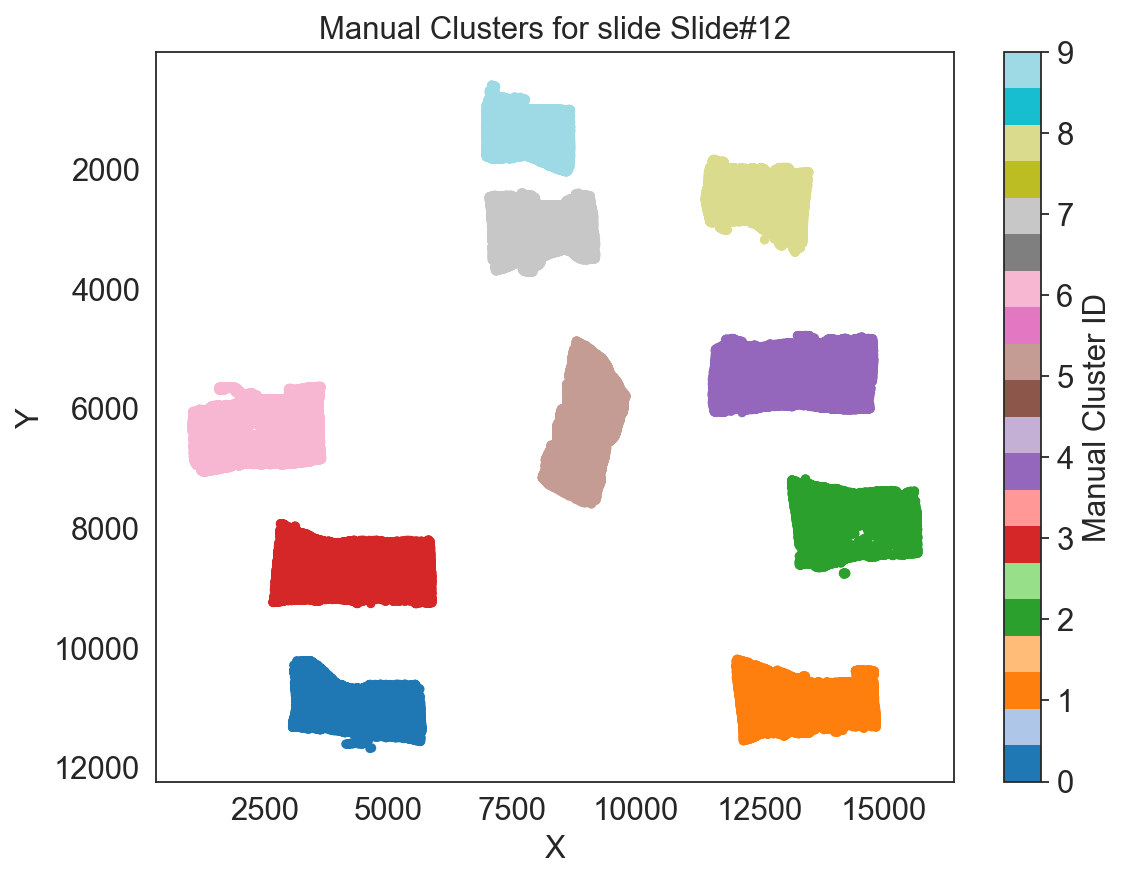

In [9]:
# Visualize the selected ROI

import matplotlib.pyplot as plt

col_name = f"manual_cluster_slide_Slide#12"
idx = adata.obs['slide'] == 'Slide#12'
coords = adata.obsm['spatial'][idx]
clusters = adata.obs.loc[idx, col_name]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=clusters, cmap='tab20', s=10)
plt.gca().invert_yaxis()  # invert y if needed to match Napari's coordinate system
plt.colorbar(scatter, label='Manual Cluster ID')
plt.title(f"Manual Clusters for slide Slide#12")
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [10]:
# Rename the ROI

manual_anno = {
    0: 'crush_d3_1',
    1: 'crush_d3_2',
    2: 'crush_d3_3',
    3: 'crush_d3_4', 
    4: 'crush_d14_1', 
    5: 'crush_d14_2', 
    6: 'crush_d14_3',
    7: 'crush_d14_4', 
    8: 'crush_d14_5', 
    9: 'crush_d14_6'
}

adata.obs['manual_anno'] = adata.obs['manual_cluster_slide_Slide#12'].map(manual_anno)

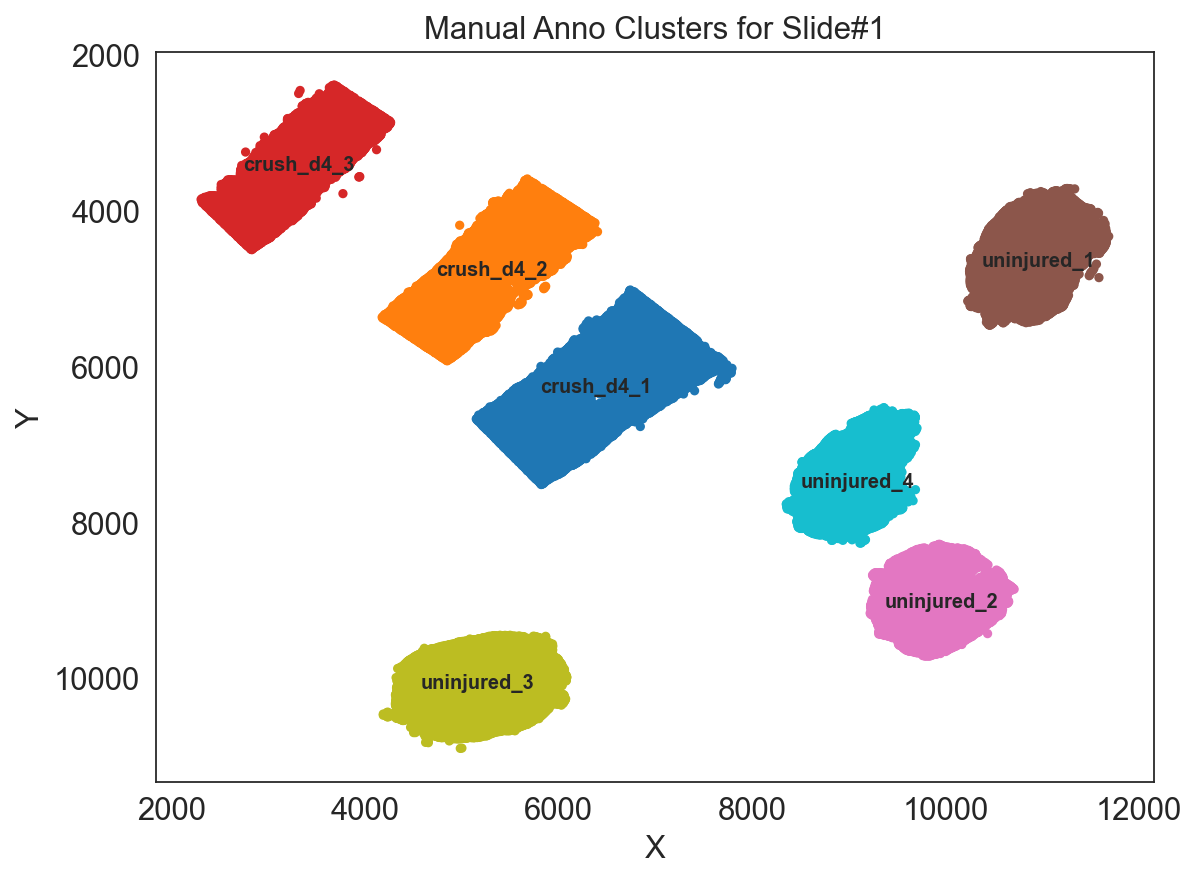

In [11]:
#Visualize the manual_anno on the sections

col_name = "manual_anno"
idx = adata.obs['slide'] == 'Slide#1'
coords = adata.obsm['spatial'][idx]
clusters = adata.obs.loc[idx, col_name]

unique_labels = clusters.unique()

plt.figure(figsize=(8, 6))
scatter = plt.scatter(coords[:, 0], coords[:, 1], s=10, c=clusters.astype('category').cat.codes, cmap='tab10')
plt.gca().invert_yaxis()
plt.title("Manual Anno Clusters for Slide#1")
plt.xlabel('X')
plt.ylabel('Y')

# Annotate cluster names at centroids
for label in unique_labels:
    mask = clusters == label
    x_mean = coords[mask, 0].mean()
    y_mean = coords[mask, 1].mean()
    plt.text(
        x_mean, y_mean, str(label),
        fontsize=9, weight='bold',
        ha='center', va='center')

plt.show()


In [12]:
#save the slide with all the sections in
adata.write("/Users/anajul/Desktop/Goritz_Lab/Spatial_transcriptomic/Analyse_3/Slide12_all.h5ad")

In [13]:
#Save all the sections individually

import scanpy as sc
import os

# Output directory
save_dir = "/Users/anajul/Desktop/Goritz_Lab/Spatial_transcriptomic/Analyse_3/per_section"
os.makedirs(save_dir, exist_ok=True)

# Ensure manual_anno exists
if "manual_anno" not in adata.obs.columns:
    raise KeyError("'manual_anno' column not found in adata.obs")

# Split and save
for cluster in adata.obs["manual_anno"].unique():
    cluster_str = str(cluster)
    adata_cluster = adata[adata.obs["manual_anno"] == cluster].copy()
    file_path = os.path.join(save_dir, f"{cluster_str}.h5ad")
    adata_cluster.write_h5ad(file_path)
    print(f"✅ Saved {cluster_str} ({adata_cluster.n_obs} cells) to {file_path}")

✅ Saved crush_d3_1 (16300 cells) to /Users/anajul/Desktop/Goritz_Lab/Spatial_transcriptomic/Analyse_3/per_section/crush_d3_1.h5ad
✅ Saved crush_d3_3 (14521 cells) to /Users/anajul/Desktop/Goritz_Lab/Spatial_transcriptomic/Analyse_3/per_section/crush_d3_3.h5ad
✅ Saved crush_d3_2 (17759 cells) to /Users/anajul/Desktop/Goritz_Lab/Spatial_transcriptomic/Analyse_3/per_section/crush_d3_2.h5ad
✅ Saved crush_d3_4 (23072 cells) to /Users/anajul/Desktop/Goritz_Lab/Spatial_transcriptomic/Analyse_3/per_section/crush_d3_4.h5ad
✅ Saved crush_d14_3 (41474 cells) to /Users/anajul/Desktop/Goritz_Lab/Spatial_transcriptomic/Analyse_3/per_section/crush_d14_3.h5ad
✅ Saved crush_d14_2 (25860 cells) to /Users/anajul/Desktop/Goritz_Lab/Spatial_transcriptomic/Analyse_3/per_section/crush_d14_2.h5ad
✅ Saved crush_d14_1 (30506 cells) to /Users/anajul/Desktop/Goritz_Lab/Spatial_transcriptomic/Analyse_3/per_section/crush_d14_1.h5ad
✅ Saved crush_d14_4 (21994 cells) to /Users/anajul/Desktop/Goritz_Lab/Spatial_transc